In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_style("whitegrid")


alloy_data = pd.read_csv(
    "../source_data/alloy_data.csv",
    sep=";",
    encoding="utf-8-sig",
    thousands=",",
    parse_dates=["last_sale_date"],
    dtype={
        "property_id": "string",
        "zip_code": "string",   # keep as string to preserve leading zeros
        "assessor_id": "string",
        "owner_occupied": "boolean",
    },
)

# Clean column names: remove BOM and strip whitespace
alloy_data.columns = alloy_data.columns.str.replace("\ufeff", "", regex=False).str.strip()

print(f"Shape: {alloy_data.shape}")
alloy_data.head()

Shape: (2090, 28)


,property_id,id,full_address,street_address,unit,city,state,zip_code,county,latitude,longitude,property_type,bedrooms,bathrooms,sqft,lot_size_sqft,year_built,building_age,last_sale_price,last_sale_date,days_since_sale,price_per_sqft,assessed_value,tax_year,annual_tax,owner_name,owner_occupied,assessor_id
0,P-100001,10001,"1924 Oak Ave, Honolulu, HI 46048",1924 Oak Ave,NaN,Honolulu,HI,46048,Honolulu,27.49,-144.86,Single Family,6,5.00,1312,10986,1974,50,"546,937.17",2025-03-26,384,416.87,"473,424.11",2024,"7,207.52",Emily Gonzalez,False,HI-HO-81426
1,P-100002,10002,"3711 Harbor View Blvd, Pittsburgh, PA 87236",3711 Harbor View Blvd,NaN,Pittsburgh,PA,87236,Allegheny,28.37,-81.37,Single Family,6,4.00,3387,7939,1939,85,"287,944.73",2017-09-20,3128,85.01,"259,431.97",2022,"3,258.24",Matthew Thompson,False,PA-AL-15695
2,P-100003,10003,"8885 Park Way, Apt 21C, Kansas City, MO 59615",8885 Park Way,Apt 21C,Kansas City,MO,59615,Jackson,23.09,-131.49,Townhouse,7,3.50,5329,8479,2010,14,"174,253.02",2018-11-13,2709,32.70,"151,316.00",2023,"2,999.49",Joseph Miller,True,MO-JA-69429
3,P-100004,10004,"6165 Hillcrest Ave, Bronx, NY 37460",6165 Hillcrest Ave,NaN,Bronx,NY,37460,Bronx,38.76,-95.94,Single Family,5,2.00,4975,16921,1951,73,"948,377.61",2022-01-10,1555,190.63,"835,505.83",2024,"18,381.13",Joseph Baker,True,NY-BR-17331
4,P-100005,10005,"625 Ridgewood Rd, Apt 14E, Tucson, AZ 62581",625 Ridgewood Rd,Apt 14E,Tucson,AZ,62581,Pima,28.10,-138.64,Townhouse,6,3.50,2341,13079,1983,41,"428,592.88",2019-01-27,2634,183.08,"401,872.50",2023,"3,888.34",Deborah Scott,True,AZ-PI-86622


In [2]:
# Dtypes and non-null counts
print("=== DTYPES & NON-NULLS ===")
alloy_data.info()

# Exact row duplicates
print(f"\nExact duplicate rows: {alloy_data.duplicated().sum()}")

# Key uniqueness — property_id should be unique
print(f"Duplicate property_ids: {alloy_data['property_id'].duplicated().sum()}")
print(f"Duplicate ids: {alloy_data['id'].duplicated().sum()}")

# Are property_id and id 1-to-1? If yes, one is redundant.
one_to_one = (alloy_data.groupby("property_id")["id"].nunique().max() == 1) and \
             (alloy_data.groupby("id")["property_id"].nunique().max() == 1)
print(f"property_id and id are 1-to-1: {one_to_one}")

=== DTYPES & NON-NULLS ===
<class 'pandas.DataFrame'>
RangeIndex: 2090 entries, 0 to 2089
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   property_id      2090 non-null   str           
 1   id               2090 non-null   int64         
 2   full_address     2090 non-null   str           
 3   street_address   2090 non-null   str           
 4   unit             1052 non-null   str           
 5   city             2090 non-null   str           
 6   state            2090 non-null   str           
 7   zip_code         2090 non-null   string        
 8   county           2090 non-null   str           
 9   latitude         2090 non-null   float64       
 10  longitude        2090 non-null   float64       
 11  property_type    2090 non-null   str           
 12  bedrooms         2090 non-null   int64         
 13  bathrooms        2090 non-null   float64       
 14  sqft             2090 no

id column and property column are the same. Mostly likely id column is redundant of the property column. Before modelling, I'll drop one.

In [ ]:
# Missing values check
missing_counts = alloy_data.isna().sum().sort_values(ascending=False)
missing_pct = (alloy_data.isna().mean() * 100).round(2).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct,
})
print(missing_report[missing_report["missing_count"] > 0])

# check missing columns to see if missingness is structural
# Example: is `unit` NaN mainly for Single Family homes? (expected — they have no unit number)
if alloy_data["unit"].isna().any():
    print("\n=== `unit` missingness by property_type ===")
    print(pd.crosstab(alloy_data["property_type"], alloy_data["unit"].isna(), margins=True))

      missing_count  missing_pct
unit           1038        49.67

=== `unit` missingness by property_type ===
unit           False  True   All
property_type                   
Condo            624     0   624
Multi Family       0   209   209
Single Family      0   829   829
Townhouse        428     0   428
All             1052  1038  2090


Only the unit column has missing values. The category with the most missing value is Single Family houses, which is expected not to have a unit number. Same with Multi family homes. The missingness is structural then.

In [ ]:
# for dashboarding purposes, fill NaNs in `unit` with "N/A" to indicate no unit number (common for Single Family homes)
alloy_data["unit"] = alloy_data["unit"].fillna("N/A")

In [5]:
alloy_data.head()

,property_id,id,full_address,street_address,unit,city,state,zip_code,county,latitude,longitude,property_type,bedrooms,bathrooms,sqft,lot_size_sqft,year_built,building_age,last_sale_price,last_sale_date,days_since_sale,price_per_sqft,assessed_value,tax_year,annual_tax,owner_name,owner_occupied,assessor_id
0,P-100001,10001,"1924 Oak Ave, Honolulu, HI 46048",1924 Oak Ave,N/A,Honolulu,HI,46048,Honolulu,27.49,-144.86,Single Family,6,5.00,1312,10986,1974,50,"546,937.17",2025-03-26,384,416.87,"473,424.11",2024,"7,207.52",Emily Gonzalez,False,HI-HO-81426
1,P-100002,10002,"3711 Harbor View Blvd, Pittsburgh, PA 87236",3711 Harbor View Blvd,N/A,Pittsburgh,PA,87236,Allegheny,28.37,-81.37,Single Family,6,4.00,3387,7939,1939,85,"287,944.73",2017-09-20,3128,85.01,"259,431.97",2022,"3,258.24",Matthew Thompson,False,PA-AL-15695
2,P-100003,10003,"8885 Park Way, Apt 21C, Kansas City, MO 59615",8885 Park Way,Apt 21C,Kansas City,MO,59615,Jackson,23.09,-131.49,Townhouse,7,3.50,5329,8479,2010,14,"174,253.02",2018-11-13,2709,32.70,"151,316.00",2023,"2,999.49",Joseph Miller,True,MO-JA-69429
3,P-100004,10004,"6165 Hillcrest Ave, Bronx, NY 37460",6165 Hillcrest Ave,N/A,Bronx,NY,37460,Bronx,38.76,-95.94,Single Family,5,2.00,4975,16921,1951,73,"948,377.61",2022-01-10,1555,190.63,"835,505.83",2024,"18,381.13",Joseph Baker,True,NY-BR-17331
4,P-100005,10005,"625 Ridgewood Rd, Apt 14E, Tucson, AZ 62581",625 Ridgewood Rd,Apt 14E,Tucson,AZ,62581,Pima,28.10,-138.64,Townhouse,6,3.50,2341,13079,1983,41,"428,592.88",2019-01-27,2634,183.08,"401,872.50",2023,"3,888.34",Deborah Scott,True,AZ-PI-86622


In [6]:
# Full summary — read every row carefully
print("=== describe() ===")
print(alloy_data.describe().T)

# Explicit plausibility checks per column
print("\n=== PLAUSIBILITY FLAGS ===")

flags = {
    "bedrooms_suspicious": (alloy_data["bedrooms"] < 0) | (alloy_data["bedrooms"] > 15),
    "bathrooms_suspicious": (alloy_data["bathrooms"] < 0) | (alloy_data["bathrooms"] > 15),
    "sqft_suspicious": (alloy_data["sqft"] < 200) | (alloy_data["sqft"] > 30000),
    "lot_size_suspicious": (alloy_data["lot_size_sqft"] <= 0) | (alloy_data["lot_size_sqft"] > 1_000_000),
    "year_built_suspicious": (alloy_data["year_built"] < 1800) | (alloy_data["year_built"] > 2026),
    # Rough US bounding box — continental, HI, and AK
    "latitude_suspicious": (alloy_data["latitude"] < 18) | (alloy_data["latitude"] > 72),
    "longitude_suspicious": (alloy_data["longitude"] > -66) | (alloy_data["longitude"] < -180),
    "sale_price_suspicious": (alloy_data["last_sale_price"] <= 0) | (alloy_data["last_sale_price"] > 50_000_000),
    "ppsqft_suspicious": (alloy_data["price_per_sqft"] < 20) | (alloy_data["price_per_sqft"] > 5000),
    "tax_year_suspicious": (alloy_data["tax_year"] < 2000) | (alloy_data["tax_year"] > 2026),
}

for name, mask in flags.items():
    count = mask.sum()
    if count > 0:
        print(f"  {name}: {count} rows")

=== describe() ===
                   count                        mean                  min                  25%                  50%                  75%                  max        std
id              2,090.00                   11,111.93            10,001.00            10,556.50            11,112.50            11,667.75            12,226.00     641.85
latitude        2,090.00                       34.22                21.01                27.71                33.92                40.98                47.46       7.62
longitude       2,090.00                     -113.97              -156.99              -135.82              -114.56               -91.44               -70.00      25.34
bedrooms        2,090.00                        4.00                 1.00                 2.00                 4.00                 6.00                 7.00       2.00
bathrooms       2,090.00                        2.98                 1.00                 2.00                 3.00                 4.00

Interesting — the plausibility flags section is empty, which means every numeric column passed the plausibility check. No bedrooms over 15, no zero-sqft, no impossible years, nothing. Not bad. Things can be straightforward for once. Almost makes me want to laugh. But the some coordinates feels weird though. Like I've already spotted Honnulu and Pittsburgh which doesn't match what Google is giving me. Let me try something:

In [8]:
# Do coordinates roughly match state?
# Very loose state bounding boxes (min_lat, max_lat, min_lon, max_lon)
STATE_BBOX = {
    "CA": (32.5, 42.0, -124.5, -114.0),
    "NY": (40.5, 45.0, -79.8, -71.8),
    "TX": (25.8, 36.5, -106.7, -93.5),
    "FL": (24.5, 31.0, -87.6, -80.0),
    "IL": (36.9, 42.5, -91.5, -87.0),
    "HI": (18.9, 22.2, -160.3, -154.8),
    "PA": (39.7, 42.3, -80.6, -74.7),
    "MO": (36.0, 40.6, -95.8, -89.1),
    "AZ": (31.3, 37.0, -114.8, -109.0),
}

def coord_matches_state(row):
    bbox = STATE_BBOX.get(row["state"])
    if bbox is None:
        return None  # state not in our lookup — can't judge
    min_lat, max_lat, min_lon, max_lon = bbox
    return (min_lat <= row["latitude"] <= max_lat) and (min_lon <= row["longitude"] <= max_lon)

alloy_data["coord_matches_state"] = alloy_data.apply(coord_matches_state, axis=1)

# How many rows have coordinates outside their stated state's bbox?
mismatch_count = (alloy_data["coord_matches_state"] == False).sum()
match_count = (alloy_data["coord_matches_state"] == True).sum()
total_judged = match_count + mismatch_count
print(f"Rows we can judge: {total_judged}")
print(f"Match: {match_count} ({100*match_count/total_judged:.1f}%)")
print(f"Mismatch: {mismatch_count} ({100*mismatch_count/total_judged:.1f}%)")

# Show a sample of mismatches
print("\nSample mismatches:")
print(alloy_data[alloy_data["coord_matches_state"] == False][["city", "state", "latitude", "longitude"]].head(10))

Rows we can judge: 841
Match: 26 (3.1%)
Mismatch: 815 (96.9%)

Sample mismatches:
           city state  latitude  longitude
0      Honolulu    HI     27.49    -144.86
1    Pittsburgh    PA     28.37     -81.37
2   Kansas City    MO     23.09    -131.49
3         Bronx    NY     38.76     -95.94
4        Tucson    AZ     28.10    -138.64
6       Houston    TX     30.01    -131.47
9        Tucson    AZ     22.88    -102.09
13        Bronx    NY     43.56    -151.04
14   Naperville    IL     31.49     -98.56
16   Naperville    IL     43.60    -113.03


`latitude` and `longitude` are unreliable. Of 841 rows tested against their stated state's bounding box, only 3.1% matched. It means that most coordinates appear randomly distributed within the US, with no relationship to each property's stated city/state. Since we still have other geo-informative columns like state, city and zip code, we can drop both latitude and lobgitude columns from the feature set and rely on `city`, `state`, `zip_code`, and `county` for location encoding.

In [9]:
categorical_cols = ["property_type", "state", "owner_occupied"]
for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(alloy_data[col].value_counts(dropna=False))

# Top cities (just the top 20)
print("\n=== Top 20 cities ===")
print(alloy_data["city"].value_counts().head(20))

# State-city consistency: does each city map to one state?
city_state_conflicts = (
    alloy_data.groupby("city")["state"]
    .nunique()
    .sort_values(ascending=False)
)
print("\n=== Cities appearing in multiple states (data quality issue) ===")
print(city_state_conflicts[city_state_conflicts > 1])

# US state codes — flag anything that isn't one
US_STATES = {
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA","HI","ID","IL","IN","IA",
    "KS","KY","LA","ME","MD","MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC","SD","TN","TX","UT","VT",
    "VA","WA","WV","WI","WY","DC"
}
bad_states = set(alloy_data["state"].dropna().unique()) - US_STATES
print(f"\nNon-US state codes: {bad_states if bad_states else 'none'}")


=== property_type ===
property_type
Single Family    829
Condo            624
Townhouse        428
Multi Family     209
Name: count, dtype: int64

=== state ===
state
TX    148
FL    146
CA    129
NY    124
NC     85
GA     83
IL     77
AZ     74
NV     73
TN     73
MI     68
CO     68
OH     64
MO     63
KY     63
WA     63
PA     57
LA     57
OK     56
IN     53
MD     53
MA     52
UT     50
SC     47
VA     45
OR     44
MN     43
NM     26
HI     23
ID     23
KS     23
MT     22
NE     15
Name: count, dtype: int64

=== owner_occupied ===
owner_occupied
True     1236
False     854
Name: count, dtype: Int64

=== Top 20 cities ===
city
Austin             42
Charlotte          41
Lexington          40
Jacksonville       36
Tampa              36
St. Louis          33
New Orleans        33
Pittsburgh         32
Tulsa              32
Atlanta            31
Kansas City        30
Boston             30
Rockville          29
Reno               29
Nashville          29
Waukegan           29
Hen

In [ ]:
# check distribution for owner_occupied, zip code and city.
print("=== owner_occupied ===")
print(alloy_data["owner_occupied"].value_counts(dropna=False))
print(f"\n=== Top 20 cities ===")
print(alloy_data["city"].value_counts().head(20))
print(f"\nUnique cities: {alloy_data['city'].nunique()}")
print(f"Unique counties: {alloy_data['county'].nunique()}")
print(f"Unique zip codes: {alloy_data['zip_code'].nunique()}")

=== owner_occupied ===
owner_occupied
True     1236
False     854
Name: count, dtype: Int64

=== Top 20 cities ===
city
Austin             42
Charlotte          41
Lexington          40
Jacksonville       36
Tampa              36
St. Louis          33
New Orleans        33
Pittsburgh         32
Tulsa              32
Atlanta            31
Kansas City        30
Boston             30
Rockville          29
Reno               29
Nashville          29
Waukegan           29
Henderson          29
Tucson             28
Naperville         28
Fort Lauderdale    28
Name: count, dtype: int64

Unique cities: 84
Unique counties: 80
Unique zip codes: 2064


`owner_occupied` distribution is roughly equal, which is a strong feature characteristic for a binary column. `city` column unique values which makes sense, but I don't understand why zip codes will be so many comapred to how many rows we have in the dataset (2064 compared to 2090 in total). Does that mean nearly every sale was in a separate zip code?

In [11]:
# shape of the first 20 zip codes
print("Sample zip codes:")
print(alloy_data["zip_code"].head(20).tolist())

# Length distribution
print(f"\nZip code length distribution:")
print(alloy_data["zip_code"].str.len().value_counts())

# Any non-digit characters?
print(f"\nAny non-numeric zips: {(~alloy_data['zip_code'].str.match(r'^\d+$')).sum()}")

Sample zip codes:
['46048', '87236', '59615', '37460', '62581', '28131', '94012', '88504', '79163', '10942', '96374', '42742', '69638', '20500', '44814', '30676', '93130', '19862', '91351', '70332']

Zip code length distribution:
zip_code
5    2090
Name: count, dtype: Int64

Any non-numeric zips: 0


No wonder. Seems like the values are randomly distributed 5-digit numbers (like with latitude and longitude) with no relationship to the stated city or state (e.g., Honolulu, HI paired with zip 46048, an Indiana zip; Pittsburgh, PA paired with 87236, an unassigned code). It's unreliable. We would need to drop `zip_code` from the feature set. Location signal will just come from `city`, `state`, and `county`.

#### Common Sense Checks

In [13]:
current_year = datetime.now().year

# building_age + year_built should equal a consistent "current year"
age_check = alloy_data["building_age"] + alloy_data["year_built"]
print(f"building_age + year_built — min: {age_check.min()}, max: {age_check.max()}")

# last_sale_price / sqft should equal price_per_sqft
computed_ppsqft = alloy_data["last_sale_price"] / alloy_data["sqft"]
diff = (computed_ppsqft - alloy_data["price_per_sqft"]).abs()
mismatches = (diff > 1.0).sum()  # tolerance of $1
print(f"\nprice_per_sqft mismatches: {mismatches}")

# days_since_sale vs last_sale_date
today = pd.Timestamp(datetime.now().date())
computed_days = (today - alloy_data["last_sale_date"]).dt.days
day_diff = (computed_days - alloy_data["days_since_sale"]).abs()
print(f"\ndays_since_sale — mean difference from computed: {day_diff.mean():.1f} days") # a small constant offset is fine; large variance suggests it was frozen at different times


# assessed_value should be positive and roughly in line with sale price
ratio = alloy_data["assessed_value"] / alloy_data["last_sale_price"]
print(f"\nassessed_value / last_sale_price ratio — describe:")
print(ratio.describe()) # ratios below 0.3 or above 1.5 would be suspicious

building_age + year_built — min: 2024, max: 2024

price_per_sqft mismatches: 0

days_since_sale — mean difference from computed: 10.0 days

assessed_value / last_sale_price ratio — describe:
count   2,090.00
mean        0.95
std         0.09
min         0.80
25%         0.87
50%         0.95
75%         1.02
max         1.10
dtype: float64


Since `building_age` and `year_built` are roughly the same, We can drop one during modelling. Also now I think of it, if we are using `days_since_sale`, we'd have to recompute it fresh from `last_sale_date`.

The assessed_value / last_sale_price ratio is interesting because the variance is low, and with the mean, the value for last_sale_price (which is our target) can be easily gotten. Will be too easy for our trained model. For the model to learn well, we would likely exclude the column.

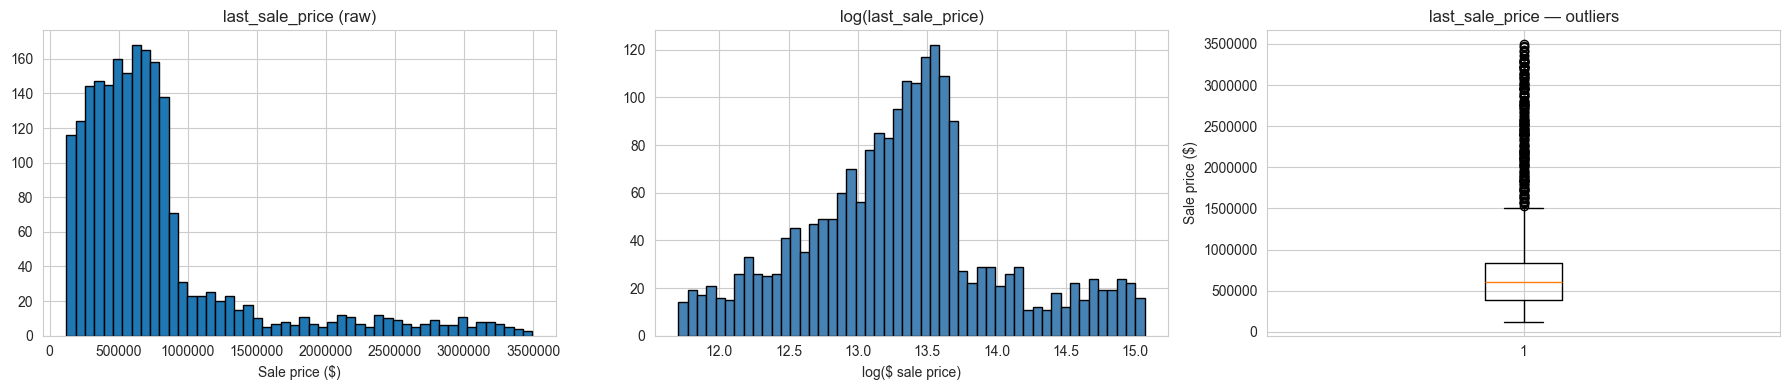

min: $121,231
max: $3,495,036
median: $611,406
mean: $781,993
skew: 2.14  (0 = normal, >1 = right-skewed)
zeros or negatives: 0


In [ ]:
# Target variable distribution

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Raw distribution
axes[0].hist(alloy_data["last_sale_price"], bins=50, edgecolor="black")
axes[0].set_title("last_sale_price (raw)")
axes[0].set_xlabel("Sale price ($)")
axes[0].ticklabel_format(style="plain", axis="x")

# Log-transformed
axes[1].hist(np.log1p(alloy_data["last_sale_price"]), bins=50, edgecolor="black", color="steelblue")
axes[1].set_title("log(last_sale_price)")
axes[1].set_xlabel("log($ sale price)")

# Boxplot to show outliers
axes[2].boxplot(alloy_data["last_sale_price"].dropna(), vert=True)
axes[2].set_title("last_sale_price — outliers")
axes[2].set_ylabel("Sale price ($)")
axes[2].ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

# Target summary
print(f"min: ${alloy_data['last_sale_price'].min():,.0f}")
print(f"max: ${alloy_data['last_sale_price'].max():,.0f}")
print(f"median: ${alloy_data['last_sale_price'].median():,.0f}")
print(f"mean: ${alloy_data['last_sale_price'].mean():,.0f}")
print(f"skew: {alloy_data['last_sale_price'].skew():.2f}  (0 = normal, >1 = right-skewed)")
print(f"zeros or negatives: {(alloy_data['last_sale_price'] <= 0).sum()}")

This means it'll be safer to log transform our target column, for normality purposes

In [15]:
# Look at the top 20 most expensive properties to sanity check
top_20 = alloy_data.nlargest(20, "last_sale_price")[
    ["property_id", "city", "state", "property_type", "sqft", "bedrooms", "last_sale_price", "price_per_sqft"]
]
print(top_20)

# And the cheapest 20
print("\n--- Cheapest 20 ---")
bottom_20 = alloy_data.nsmallest(20, "last_sale_price")[
    ["property_id", "city", "state", "property_type", "sqft", "bedrooms", "last_sale_price", "price_per_sqft"]
]
print(bottom_20)

     property_id           city state  property_type  sqft  bedrooms  last_sale_price  price_per_sqft
652     P-100695      Manhattan    NY  Single Family  3995         7     3,495,036.42          874.85
1367    P-101458  San Francisco    CA  Single Family  4868         7     3,470,501.71          712.92
1969    P-102096        Seattle    WA   Multi Family  4474         7     3,462,480.32          773.91
1728    P-101840         Irvine    CA  Single Family  4727         1     3,420,666.60          723.64
929     P-100987         Boston    MA  Single Family  5261         6     3,417,076.78          649.51
1768    P-101882         Boston    MA      Townhouse  4472         2     3,399,396.61          760.15
911     P-100968      San Diego    CA   Multi Family  6174         5     3,368,792.37          545.64
75      P-100081      Manhattan    NY   Multi Family  4888         2     3,357,881.22          686.96
542     P-100577         Irvine    CA      Townhouse  4233         7     3,321,352

Some rows have physically implausible size/price pairings at the low end (20 cheapest). A 6,127 sqft condo in Reno selling for $125K is doesn't seem right at all. You can't buy a 6,000 sqft condo anywhere in the US for $125K — the construction cost alone would be 3–4x that. A $20–$35/sqft sale price for a 4,000–6,000 sqft property doesn't match economic reality in any market. Maybe, the low-end of the price distribution was generated independently of the size.

In [ ]:
very_low = alloy_data[alloy_data["price_per_sqft"] < 50]
low = alloy_data[alloy_data["price_per_sqft"] < 75]

print(f"Rows with price_per_sqft < $50: {len(very_low)} ({100*len(very_low)/len(alloy_data):.1f}%)")
print(f"Rows with price_per_sqft < $75: {len(low)} ({100*len(low)/len(alloy_data):.1f}%)")

# Distribution by property type for the very-low group
print("\nVery-low rows by property type:")
print(very_low["property_type"].value_counts())

# Distribution by state
print("\nVery-low rows by state (top 10):")
print(very_low["state"].value_counts().head(10))

# Look at the full price_per_sqft distribution
print("\nprice_per_sqft percentiles:")
print(alloy_data["price_per_sqft"].quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

Rows with price_per_sqft < $50: 134 (6.4%)
Rows with price_per_sqft < $75: 307 (14.7%)

Very-low rows by property type:
property_type
Single Family    58
Townhouse        33
Condo            29
Multi Family     14
Name: count, dtype: int64

Very-low rows by state (top 10):
state
FL    13
NC    11
TX     9
TN     9
MI     8
NV     8
AZ     7
IL     7
OK     7
MO     6
Name: count, dtype: int64

price_per_sqft percentiles:
0.01    27.35
0.05    45.63
0.10    61.30
0.25   105.02
0.50   171.88
0.75   350.64
0.90   585.71
0.95   723.96
0.99   933.11
Name: price_per_sqft, dtype: float64


Hmmm, some plausible context here. I think what we'll do is drop the 134 rows with price_per_sqft < $50 because these are physically impossible given average US construction costs from [Google](https://www.google.com/search?q=average+price%2Fsqft+for+US+construction+costs&sca_esv=678aa669decbf740&sxsrf=ANbL-n7HRBHSICNA0DfSSgAg38EJ5dSbKQ%3A1777037776706&source=hp&ei=0HHradH8KIuohbIPtrq1wQE&iflsig=AFdpzrgAAAAAaet_4Bgpeb49BMGZMWWRr83pQ-hgX_u_&ved=0ahUKEwjRpLnLzYaUAxULVEEAHTZdLRgQ4dUDCCQ&uact=5&oq=average+price%2Fsqft+for+US+construction+costs&gs_lp=Egdnd3Mtd2l6IixhdmVyYWdlIHByaWNlL3NxZnQgZm9yIFVTIGNvbnN0cnVjdGlvbiBjb3N0czIFECEYoAFIv6oCUABY9qYCcAJ4AJABAJgBhwGgAcAjqgEFMjIuMjO4AQPIAQD4AQGYAi6gAsgjwgIKECMYgAQYJxiKBcICBBAjGCfCAhEQLhiABBixAxjRAxiDARjHAcICCBAAGIAEGLEDwgIOEC4YgAQYsQMY0QMYxwHCAgsQLhiABBjRAxjHAcICCBAuGIAEGLEDwgIOEC4YgAQYxwEYjgUYrwHCAgsQABiABBixAxiDAcICBRAAGIAEwgIFEC4YgATCAgsQLhiABBixAxiDAcICDhAuGIAEGLEDGMcBGK8BwgILEAAYgAQYsQMYigXCAgYQABgWGB7CAgsQABiABBiGAxiKBcICCBAAGIAEGKIEwgIIEAAYogQYiQXCAggQABgWGAoYHsICBRAAGO8FwgIHECEYoAEYCpgDAJIHBTIwLjI2oAeU_wGyBwUxOC4yNrgHwiPCBwcxNy4yOC4xyAdEgAgA&sclient=gws-wiz). That's 6.4% loss, which is tolerable. We can keep everything else, including the $50–$75 band (which is suspicious but not physically impossible and probably contains some legitimate rural data).

In [17]:
# Before
print(f"Rows before cleaning: {len(alloy_data)}")
print(f"Median last_sale_price before: ${alloy_data['last_sale_price'].median():,.0f}")

# Drop physically implausible rows
# Rationale: US construction cost alone is >$150/sqft. Sale prices below $50/sqft
# indicate data errors rather than legitimate distressed properties.
alloy_clean = alloy_data[alloy_data["price_per_sqft"] >= 50].copy()

# After
print(f"\nRows after cleaning: {len(alloy_clean)} ({len(alloy_clean)/len(alloy_data)*100:.1f}% retained)")
print(f"Rows dropped: {len(alloy_data) - len(alloy_clean)}")
print(f"Median last_sale_price after: ${alloy_clean['last_sale_price'].median():,.0f}")

# new price_per_sqft distribution
print(f"\nNew price_per_sqft percentiles:")
print(alloy_clean["price_per_sqft"].quantile([0.01, 0.05, 0.50, 0.95, 0.99]).round(2))

Rows before cleaning: 2090
Median last_sale_price before: $611,406

Rows after cleaning: 1956 (93.6% retained)
Rows dropped: 134
Median last_sale_price after: $641,333

New price_per_sqft percentiles:
0.01    54.36
0.05    63.85
0.50   185.24
0.95   741.98
0.99   934.88
Name: price_per_sqft, dtype: float64


    sale_year  median_price  mean_price  median_ppsqft  n_sales
0        2016    611,046.85  805,129.38         168.81      141
1        2017    667,145.45  728,669.89         173.29      188
2        2018    610,555.73  791,178.37         174.41      186
3        2019    635,099.80  798,046.85         183.72      198
4        2020    636,994.83  865,298.01         182.87      186
5        2021    655,290.05  844,861.69         190.35      208
6        2022    608,099.64  784,879.09         180.54      177
7        2023    670,615.16  860,283.26         205.09      188
8        2024    665,129.08  894,465.68         202.09      224
9        2025    656,694.62  844,006.16         209.08      201
10       2026    657,562.34  770,888.04         176.84       59


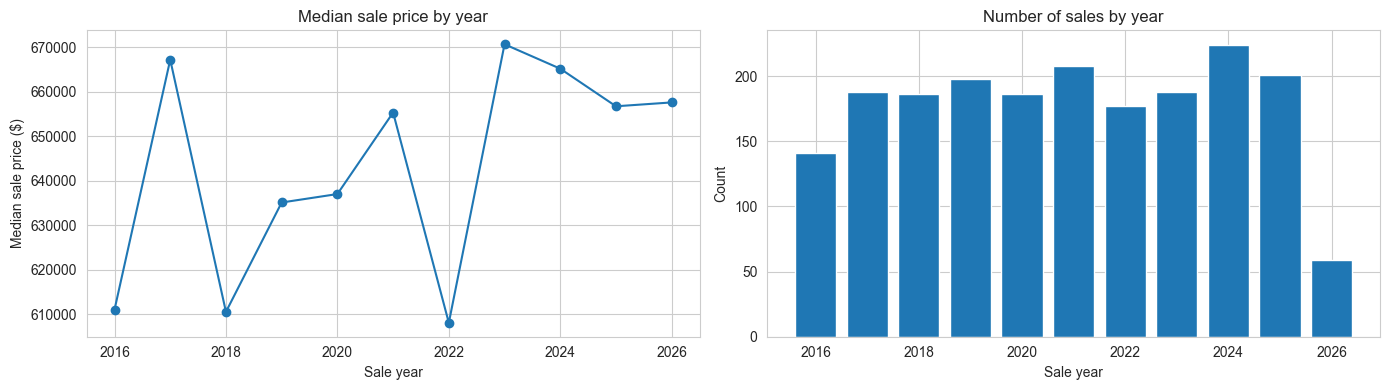

In [18]:
# Add sale_year column for time-based analysis
alloy_clean["sale_year"] = alloy_clean["last_sale_date"].dt.year

# Analyze trends over time: median price, mean price, median price_per_sqft, and count of sales by year
yearly_stats = alloy_clean.groupby("sale_year").agg(
    median_price=("last_sale_price", "median"),
    mean_price=("last_sale_price", "mean"),
    median_ppsqft=("price_per_sqft", "median"),
    n_sales=("last_sale_price", "count"),
).reset_index()

print(yearly_stats)

# Visualize trends over time: median price and count of sales by year
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(yearly_stats["sale_year"], yearly_stats["median_price"], marker="o")
axes[0].set_title("Median sale price by year")
axes[0].set_xlabel("Sale year")
axes[0].set_ylabel("Median sale price ($)")

# Count of sales by year
axes[1].bar(yearly_stats["sale_year"], yearly_stats["n_sales"])
axes[1].set_title("Number of sales by year")
axes[1].set_xlabel("Sale year")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

The median line chart reveals that maybe synthetic because it doesn't match with th number of sales by year and even the mean sale price trends. It means the signal from it for training will be weak at best. But it won't be too detrimental.

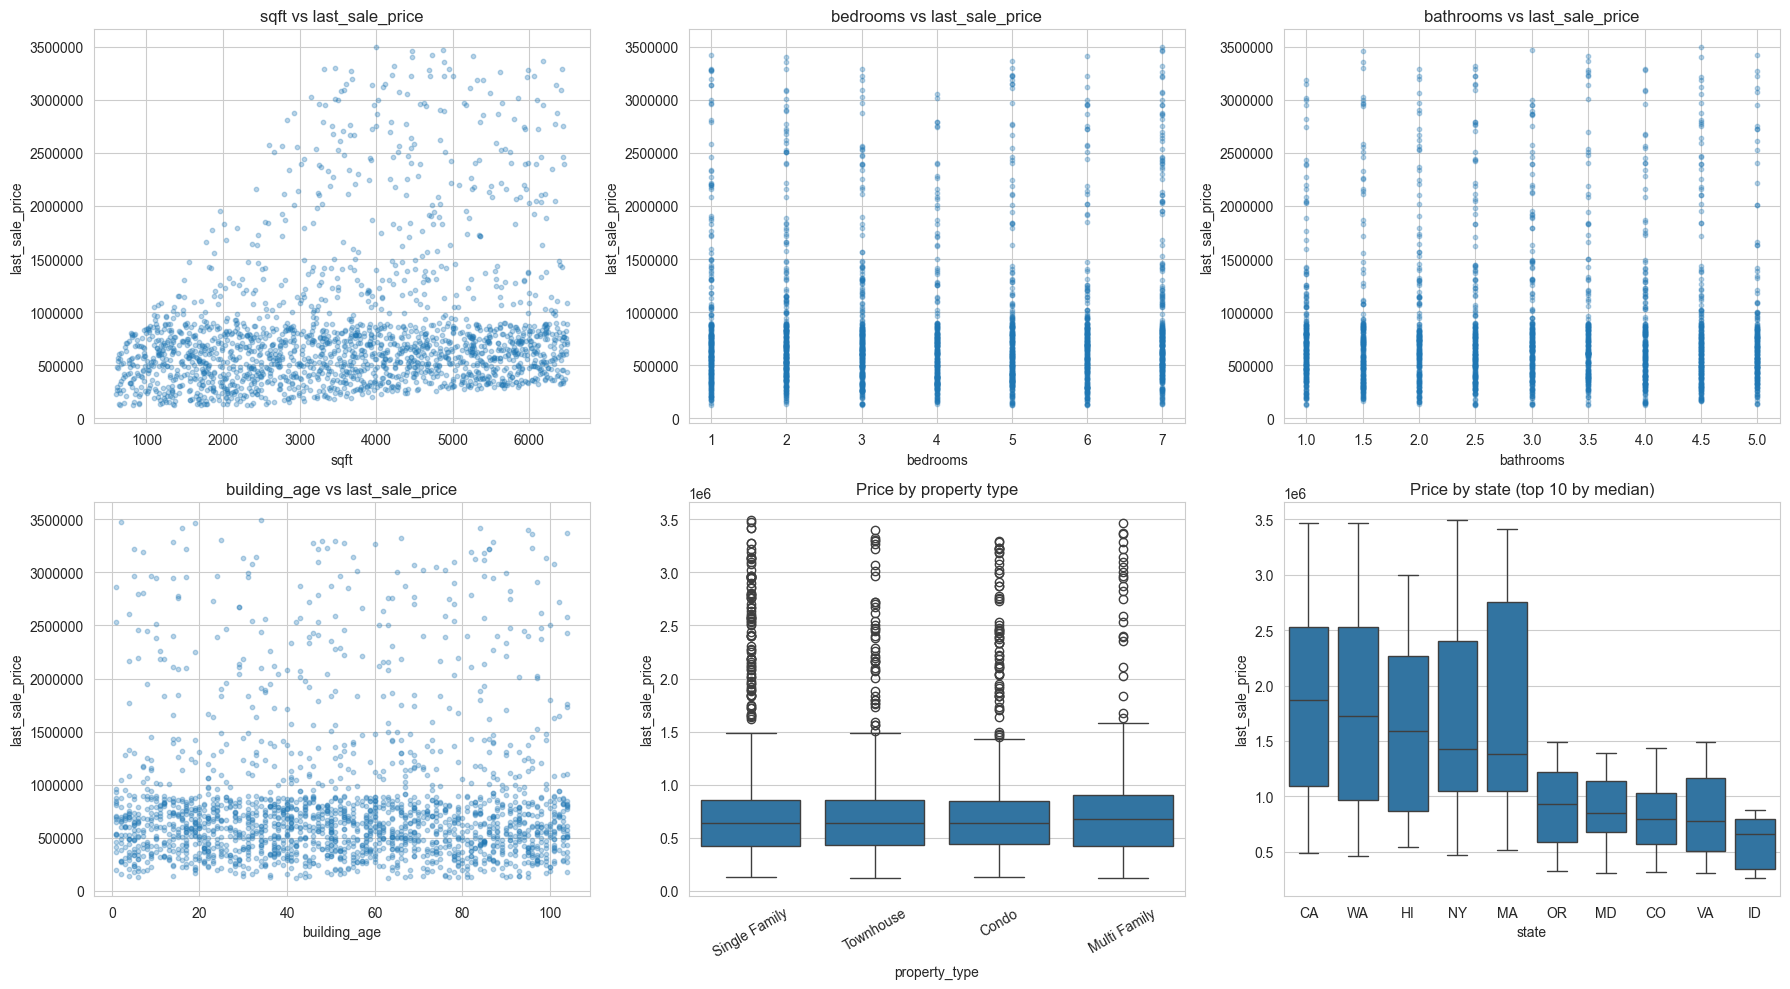

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Numeric scatters
for ax, col in zip(axes.flat[:4], ["sqft", "bedrooms", "bathrooms", "building_age"]):
    ax.scatter(alloy_clean[col], alloy_clean["last_sale_price"], alpha=0.3, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel("last_sale_price")
    ax.set_title(f"{col} vs last_sale_price")
    ax.ticklabel_format(style="plain", axis="y")

# Categorical boxplots
sns.boxplot(data=alloy_clean, x="property_type", y="last_sale_price", ax=axes[1, 1])
axes[1, 1].set_title("Price by property type")
axes[1, 1].tick_params(axis="x", rotation=30)

# Top 10 states by median price
top_states = alloy_clean.groupby("state")["last_sale_price"].median().sort_values(ascending=False).head(10).index
sns.boxplot(data=alloy_clean[alloy_clean["state"].isin(top_states)], x="state", y="last_sale_price",
            order=top_states, ax=axes[1, 2])
axes[1, 2].set_title("Price by state (top 10 by median)")

plt.tight_layout()
plt.show()

Okay, this is surprising. It's normal to expect a house physical attributes to carry strong relationship to the value and sale price. In this case, they are all weak. Instead, it's the location attribute (`state`) that carries the stronger signal. It's really making me question this dataset. However, if a model is to learn well, it'll mostly be from location attributes.

In [ ]:
# A little check before I continue
# How much variance in price is explained by state alone?
state_means = alloy_clean.groupby("state")["last_sale_price"].mean()
overall_mean = alloy_clean["last_sale_price"].mean()
between_var = ((state_means - overall_mean)**2 * alloy_clean["state"].value_counts()).sum()
total_var = ((alloy_clean["last_sale_price"] - overall_mean)**2).sum()
r_squared_state_only = between_var / total_var
print(f"R² of state alone: {r_squared_state_only:.3f}")
print(f"  (i.e., {r_squared_state_only*100:.0f}% of price variance is explained by state)")

R² of state alone: 0.566
  (i.e., 57% of price variance is explained by state)


This means `state` is the dominant predictor of `last_sale_price` in this dataset

=== Correlation with last_sale_price ===
last_sale_price    1.00
assessed_value     0.99
annual_tax         0.91
price_per_sqft     0.64
sqft               0.22
lot_size_sqft      0.13
sale_year          0.04
latitude           0.03
bedrooms           0.01
building_age       0.01
bathrooms          0.00
longitude         -0.00
year_built        -0.01
id                -0.03
tax_year          -0.03
days_since_sale   -0.04
Name: last_sale_price, dtype: float64

=== LEAKAGE FLAGS ===
  assessed_value: correlation 0.990 — LIKELY LEAKAGE


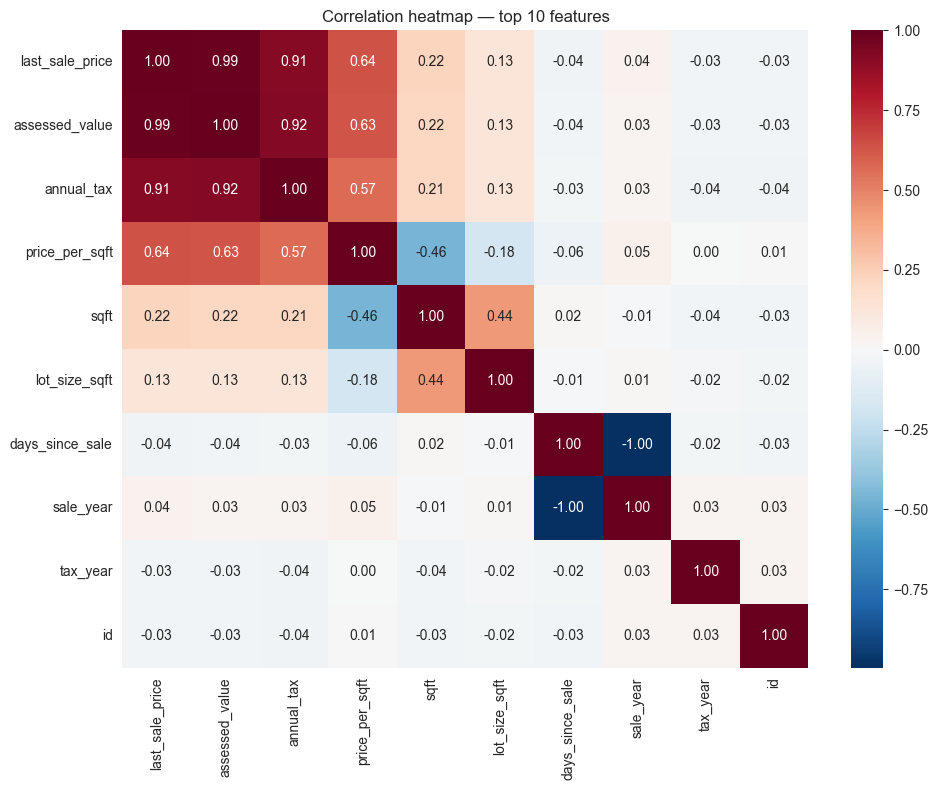

In [21]:
numeric_cols = alloy_clean.select_dtypes(include=[np.number]).columns.tolist()

# Correlations with the target, sorted
corr_with_target = alloy_clean[numeric_cols].corr()["last_sale_price"].sort_values(ascending=False)
print("=== Correlation with last_sale_price ===")
print(corr_with_target)

# Flag leakage risks
print("\n=== LEAKAGE FLAGS ===")
leakage_threshold = 0.95
for col, corr in corr_with_target.items():
    if col == "last_sale_price":
        continue
    if abs(corr) > leakage_threshold:
        print(f"  {col}: correlation {corr:.3f} — LIKELY LEAKAGE")

# Heatmap of top correlated features
top_corr_cols = corr_with_target.abs().sort_values(ascending=False).head(10).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(alloy_clean[top_corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation heatmap — top 10 features")
plt.tight_layout()
plt.show()

It's clear that `assessed_value`, `annual_tax`, and `price_per_sqft` will cause major leakage in our model. At present I'm thinking of two models for comparison purposes. One model will prioritze learning from assessed_value and the other will learn from fundamentals only.

In [ ]:
# Save the cleaned dataset for modeling
alloy_clean.to_csv("../model/alloy_data_cleaned.csv", index=False, encoding="utf-8-sig")